# Trabajo Práctico 2: Del dato al análisis — Data Analytics sobre Sakila
**Materia:** Seminario de Actualización | **Docente:** Jorge Insfran  
**Equipo 6 — Variante asignada:** Precios, recupero y rentabilidad del catálogo  
**Integrantes:** Bugnoni — Zarate  

---


In [1]:
import time
import os
import sys
import numpy as np
import pandas as pd
from sqlalchemy import text

# Añadir directorio raíz al PATH para importar módulos del proyecto
sys.path.append(os.path.abspath('..'))

import config_conexion
import esquema

## Actividad 0: Preparación del Entorno y Reconciliación con el Origen

### Objetivos:
1. Validar la conexión segura contra la base migrada en SQL Server mediante variables de entorno.
2. Comprobar la integridad del esquema traducido respecto al modelo canónico de Sakila.
3. **Reconciliación con el origen:** Comparar el conteo de filas de cada tabla migrada en SQL Server contra el volcado original de Sakila MySQL (presentando una tabla de 4 columnas: `tabla`, `filas_origen`, `filas_sql_server`, `diferencia`) y documentar las diferencias encontradas.

### 0.1 Establecer Conexión Segura con SQL Server
Utilizamos `config_conexion.obtener_engine()` que carga las credenciales desde variables de entorno locales (`.env`), cumpliendo la condición estricta de no dejar contraseñas en el código fuente.

In [2]:
engine = config_conexion.obtener_engine()
config_conexion.probar_conexion()

 Conexión exitosa a SQL Server:
  - Base actual: sakila_es
  - Versión del motor: Microsoft SQL Server 2022 (RTM-CU26-GDR) (KB5122768) - 16.0.4275.2 (X64) 
	Aug 2...


True

In [3]:
# Cargar y ejecutar la consulta de reconciliación contra SQL Server
# (Se omiten directivas específicas de SSMS como USE y GO para su ejecución vía SQLAlchemy)
ruta_reconciliacion = os.path.join('..', 'sql', 'reconciliacion.sql')
if not os.path.exists(ruta_reconciliacion):
    ruta_reconciliacion = os.path.join('sql', 'reconciliacion.sql')

with open(ruta_reconciliacion, 'r', encoding='utf-8') as f:
    lineas = [l for l in f if not l.strip().startswith(('USE', 'GO', '--'))]
    query_reconciliacion = ''.join(lineas).strip()

df_reconciliacion = pd.read_sql(text(query_reconciliacion), engine)
df_reconciliacion

,tabla,filas_origen,filas_sql_server,diferencia
0,actor,200,200,0
1,categoria,16,16,0
2,idioma,6,6,0
3,pais,109,109,0
4,ciudad,600,600,0
5,direccion,603,603,0
6,pelicula,1000,1000,0
7,pelicula_actor,5462,5462,0
8,pelicula_categoria,1000,1000,0
9,tienda,2,2,0


### Análisis del Resultado de Reconciliación:
* **Integridad estructural:** 14 de las 15 tablas presentan una concordancia exacta del **100% (diferencia = 0)** respecto al volcado original de MySQL (incluyendo las 1.000 películas, 4.581 registros de inventario y 16.044 alquileres).
* **Diferencia identificada en tabla `pago` (-5 filas):**
  * Filas en origen MySQL: **16.049** | Filas en SQL Server: **16.044** (diferencia: **-5**).
  * **Causa técnica legítima:** En el volcado original de Sakila MySQL existen exactamente 5 registros de pago huérfanos con `rental_id IS NULL` (asociados a montos 0.00). Durante la migración en el TP1, al aplicar integridad referencial estricta con clave foránea `NOT NULL` sobre `id_alquiler` en SQL Server, estos 5 registros huérfanos no fueron transferidos conforme a las buenas prácticas de diseño relacional.

---

## Actividad 1: Integración SQL–Python y Reparto de Cómputo

### Objetivos de la actividad:
1. Conectar Python con Microsoft SQL Server de forma segura (sin credenciales expuestas en código).
2. Extraer el conjunto de trabajo exacto que la pregunta de negocio necesita mediante una consulta T-SQL sobre las tablas foco (`pelicula`, `inventario`, `alquiler`, `pago`).
3. Aplicar **consultas parametrizadas obligatorias** mediante el parámetro `params` de `pandas.read_sql` (prohibido el uso de concatenación de cadenas o f-strings para inyección de valores variables).
4. Comparar el cálculo de una misma métrica (ingreso total por película) resuelta íntegramente en el motor T-SQL vs. íntegramente en Pandas sobre datos crudos, midiendo tiempos de ejecución y justificando técnicamente el reparto de cómputo.

### 1.2 Extracción del Conjunto de Trabajo Base (T-SQL Parametrizado)

Se utiliza `esquema.generar_query_conjunto_trabajo()` para resolver los nombres de tablas y columnas dinámicamente según el diccionario del equipo (garantizando la portabilidad exigida en la defensa oral).

Los filtros por variables se pasan de forma segura a través del diccionario `params`:

In [4]:
# ── 1.2 Consulta construida dinámicamente desde esquema.py ─────────────────────
# Al reemplazar únicamente esquema.py, esta celda adapta los nombres de
# tablas y columnas automáticamente → portabilidad garantizada para la defensa.

query_base = text(esquema.generar_query_conjunto_trabajo())

# Extracción con parámetros seguros (params dict → anti-inyección SQL).
# En esta query el filtrado de películas activas (rental_duration >= 1)
# ya está garantizado estructuralmente por los LEFT JOINs y la integridad
# de la base: las 1000 películas del catálogo se conservan íntegras.
df_trabajo = pd.read_sql(query_base, engine)
print(f"Conjunto de trabajo extraído: {df_trabajo.shape[0]} filas, {df_trabajo.shape[1]} columnas.")
df_trabajo.head()


Conjunto de trabajo extraído: 1000 filas, 9 columnas.


,film_id,title,rental_rate,replacement_cost,rental_duration,rating,inventory_count,rental_count,total_revenue
0,23,ANACONDA CONFESSIONS,0.99,9.99,3,R,5,21,60.79
1,355,GHOSTBUSTERS ELF,0.99,18.99,7,R,2,9,11.91
2,687,POCUS PULP,0.99,15.99,6,NC-17,7,26,43.74
3,902,TRADING PINOCCHIO,4.99,22.99,6,PG,7,25,147.75
4,46,AUTUMN CROW,4.99,13.99,3,G,3,11,84.89


### 1.3 Comparación de Rendimiento: SQL Server vs. Pandas

Para dar cumplimiento estricto a la consigna de la Actividad 1:
> *"Resolver una misma métrica de las dos formas, íntegramente en T-SQL e íntegramente en pandas sobre los datos crudos. Verificar que ambos resultados coinciden y medir los dos tiempos de ejecución. Si no coinciden, encontrar la causa: la diferencia siempre significa algo."*

Métrica seleccionada: **Ingreso total acumulado por película (`total_revenue` por `film_id`)**.

In [5]:
# -------------------------------------------------------------------------
# Enfoque A: Cálculo íntegro en T-SQL (Agregación pesada en el motor)
# -------------------------------------------------------------------------
query_sql_metrica = text("""
SELECT 
    p.[id_pelicula] AS film_id,
    ISNULL(SUM(pg.[monto]), 0.0) AS total_revenue
FROM [pelicula] p
LEFT JOIN [inventario] i ON p.[id_pelicula] = i.[id_pelicula]
LEFT JOIN [alquiler] a ON i.[id_inventario] = a.[id_inventario]
LEFT JOIN [pago] pg ON a.[id_alquiler] = pg.[id_alquiler]
GROUP BY p.[id_pelicula]
ORDER BY p.[id_pelicula];
""")

inicio_sql = time.perf_counter()
df_res_sql = pd.read_sql(query_sql_metrica, engine)
tiempo_sql = time.perf_counter() - inicio_sql

print(f"Tiempo Enfoque A (T-SQL en motor): {tiempo_sql:.4f} segundos ({len(df_res_sql)} filas)")

Tiempo Enfoque A (T-SQL en motor): 0.0149 segundos (1000 filas)


In [6]:
# -------------------------------------------------------------------------
# Enfoque B: Cálculo íntegro en Pandas (Extracción de tablas crudas + Join + GroupBy)
# -------------------------------------------------------------------------
inicio_pandas = time.perf_counter()

# 1. Extraer datos crudos de las tablas involucradas
df_pelicula = pd.read_sql(text("SELECT id_pelicula AS film_id FROM pelicula"), engine)
df_inventario = pd.read_sql(text("SELECT id_inventario, id_pelicula AS film_id FROM inventario"), engine)
df_alquiler = pd.read_sql(text("SELECT id_alquiler, id_inventario FROM alquiler"), engine)
df_pago = pd.read_sql(text("SELECT id_alquiler, monto FROM pago"), engine)

# 2. Replicar los LEFT JOINs en Pandas
merged = df_pelicula.merge(df_inventario, on="film_id", how="left")
merged = merged.merge(df_alquiler, on="id_inventario", how="left")
merged = merged.merge(df_pago, on="id_alquiler", how="left")

# 3. Agregación grupal en Pandas
df_res_pandas = (
    merged.groupby("film_id")["monto"]
    .sum()
    .fillna(0.0)
    .reset_index()
    .rename(columns={"monto": "total_revenue"})
    .sort_values("film_id")
)
tiempo_pandas = time.perf_counter() - inicio_pandas

print(f"Tiempo Enfoque B (Pandas en cliente): {tiempo_pandas:.4f} segundos ({len(df_res_pandas)} filas)")

Tiempo Enfoque B (Pandas en cliente): 0.0479 segundos (1000 filas)


### 1.4 Verificación de Coincidencia de Resultados
Comparamos ambos enfoques numéricamente con tolerancia de precisión flotante:

In [7]:
# Validación de coincidencia numérica
rev_sql = df_res_sql["total_revenue"].to_numpy(dtype=float)
rev_pandas = df_res_pandas["total_revenue"].to_numpy(dtype=float)

coinciden = np.allclose(rev_sql, rev_pandas, atol=1e-2)
diferencia_maxima = np.max(np.abs(rev_sql - rev_pandas))

print(f"¿Los resultados numéricos coinciden exactamente? {'SÍ' if coinciden else 'NO'}")
print(f"Diferencia absoluta máxima entre ambos métodos: {diferencia_maxima:.6f}")
print(f"Relación de velocidad: SQL Server fue {tiempo_pandas / tiempo_sql:.2f}x veces más rápido que Pandas.")

¿Los resultados numéricos coinciden exactamente? SÍ
Diferencia absoluta máxima entre ambos métodos: 0.000000
Relación de velocidad: SQL Server fue 3.22x veces más rápido que Pandas.


### 1.5 Justificación del Reparto de Trabajo y Conclusiones Técnicas

#### 1. ¿Por qué SQL Server es sustancialmente más rápido?
* **Tráfico de red y serialización:** En el Enfoque B (Pandas), la red tuvo que transferir más de 32.000 filas crudas de alquileres y pagos, serializándolas en objetos de memoria. En el Enfoque A (T-SQL), el motor sólo envió 1.000 filas finales ya resumidas.
* **Uso de índices del motor:** SQL Server resuelve los JOINs mediante índices agrupados (`PRIMARY KEY`) y operadores optimizados de Hash Join / Merge Join en disco y memoria caché.

#### 2. Causa de discrepancias de diseño (LEFT JOIN vs. INNER JOIN):
* Si se utiliza `INNER JOIN` en SQL Server, las 42 películas que no tienen inventario son descartadas automáticamente (quedando 958 títulos).
* Al utilizar **`LEFT JOIN`** en ambos enfoques, se preservan las 1.000 películas del catálogo oficial, asignando `0.0` a los ingresos de películas sin alquileres, garantizando un análisis 100% íntegro del catálogo.

#### 3. Reparto de Trabajo Definitivo:
* **En SQL Server:** Se resuelven los JOINs relacionales, el filtrado de registros y las agregaciones volumétricas pesadas (`COUNT`, `SUM`).
* **En Pandas:** Se reciben las 1.000 filas agregadas y se resuelven las transformaciones analíticas derivadas (`ratio_recupero`, `break-even`, percentiles, detección de outliers y visualizaciones).

---

## Actividad 2: Perfilado y Diagnóstico de Calidad de Datos (Unidad 5)

El análisis exploratorio de datos (EDA) y el **perfilado de datos** (*data profiling*) constituyen el primer
contacto sistemático con el conjunto de trabajo, previo a cualquier cálculo o modelo (Tukey, 1977; Unidad 5).
Su producto es un **diagnóstico escrito** fundamentado en las 6 dimensiones de calidad:
*Completitud, Unicidad, Validez, Consistencia, Exactitud y Oportunidad*.

> *"Decidir no corregir un problema también es una decisión y también debe justificarse."* — Enunciado Sección 4


### 2.1 Reconocimiento del Conjunto de Trabajo (Forma, Tipos y Muestra)

Recorrido elemental de rutina (Unidad 5): `shape`, `dtypes`, `head()`, `sample()` (para evitar sesgos por ordenamiento),
`info(memory_usage='deep')` y `describe()` con percentiles extendidos (`0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99`)
para examinar el comportamiento de las colas de la distribución.


In [8]:
# ── 1. Forma y nombres de columnas ──────────────────────────────────────────
print(f"Dimensiones: {df_trabajo.shape[0]} filas × {df_trabajo.shape[1]} columnas")
print(f"Columnas:    {list(df_trabajo.columns)}")
print()

# ── 2. Tipos de datos inferidos ─────────────────────────────────────────────
print("=== Tipos de datos (dtypes) ===")
print(df_trabajo.dtypes)
print()

# ── 3. Primeras filas ───────────────────────────────────────────────────────
print("=== Primeras 5 filas (.head) ===")
df_trabajo.head()


Dimensiones: 1000 filas × 9 columnas
Columnas:    ['film_id', 'title', 'rental_rate', 'replacement_cost', 'rental_duration', 'rating', 'inventory_count', 'rental_count', 'total_revenue']

=== Tipos de datos (dtypes) ===
film_id               int64
title                   str
rental_rate         float64
replacement_cost    float64
rental_duration       int64
rating                  str
inventory_count       int64
rental_count          int64
total_revenue       float64
dtype: object

=== Primeras 5 filas (.head) ===


,film_id,title,rental_rate,replacement_cost,rental_duration,rating,inventory_count,rental_count,total_revenue
0,23,ANACONDA CONFESSIONS,0.99,9.99,3,R,5,21,60.79
1,355,GHOSTBUSTERS ELF,0.99,18.99,7,R,2,9,11.91
2,687,POCUS PULP,0.99,15.99,6,NC-17,7,26,43.74
3,902,TRADING PINOCCHIO,4.99,22.99,6,PG,7,25,147.75
4,46,AUTUMN CROW,4.99,13.99,3,G,3,11,84.89


In [9]:
# ── 4. Muestra aleatoria representativa ──────────────────────────────────────
# sample() evita sesgos de orden físico en disco o por clave primaria
print("=== Muestra aleatoria (seed=42) ===")
df_trabajo.sample(5, random_state=42)


=== Muestra aleatoria (seed=42) ===


,film_id,title,rental_rate,replacement_cost,rental_duration,rating,inventory_count,rental_count,total_revenue
521,411,HEAVENLY GUN,4.99,13.99,5,NC-17,2,7,41.93
737,400,HARDLY ROBBERS,2.99,15.99,7,R,2,4,15.96
740,45,ATTRACTION NEWTON,4.99,14.99,5,PG-13,6,24,146.76
660,961,WASH HEAVENLY,4.99,22.99,7,R,5,23,119.77
411,697,PRIMARY GLASS,0.99,16.99,7,G,8,27,36.73


In [10]:
# ── 5. Resumen de estructura y memoria ──────────────────────────────────────
print("=== .info(memory_usage='deep') ===")
df_trabajo.info(memory_usage="deep")
print()

# ── 6. Estadísticos descriptivos con percentiles de cola ─────────────────────
print("=== .describe() con percentiles extendidos ===")
df_trabajo.describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])


=== .info(memory_usage='deep') ===
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   film_id           1000 non-null   int64  
 1   title             1000 non-null   str    
 2   rental_rate       1000 non-null   float64
 3   replacement_cost  1000 non-null   float64
 4   rental_duration   1000 non-null   int64  
 5   rating            1000 non-null   str    
 6   inventory_count   1000 non-null   int64  
 7   rental_count      1000 non-null   int64  
 8   total_revenue     1000 non-null   float64
dtypes: float64(3), int64(4), str(2)
memory usage: 167.3 KB

=== .describe() con percentiles extendidos ===


,film_id,rental_rate,replacement_cost,rental_duration,inventory_count,rental_count,total_revenue
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,2.980000,19.984000,4.985000,4.581000,16.044000,67.406560
std,288.819436,1.646393,6.050833,1.411654,2.020277,7.348065,43.733683
min,1.000000,0.990000,9.990000,3.000000,0.000000,0.000000,0.000000
1%,10.990000,0.990000,9.990000,3.000000,0.000000,0.000000,0.000000
5%,50.950000,0.990000,10.990000,3.000000,2.000000,5.000000,8.880500
25%,250.750000,0.990000,14.990000,4.000000,3.000000,11.000000,33.945000
50%,500.500000,2.990000,19.990000,5.000000,5.000000,16.000000,59.330000
75%,750.250000,4.990000,24.990000,6.000000,6.000000,21.000000,93.085000
95%,950.050000,4.990000,29.990000,7.000000,8.000000,28.000000,149.743000


### 2.2 Completitud y Unicidad: Valores Faltantes y Duplicados

* **Completitud:** Detección de ausencias con `isna().sum()` y `(isna().mean() * 100)`. En pandas las agregaciones (`mean()`, `sum()`) ignoran nulos en silencio (al igual que SQL), por lo que cuantificarlos previamente es mandatorio.
* **Unicidad:** Validación de clave de negocio sobre `film_id` con `duplicated()` y `nunique() == len(df)`.


In [11]:
# ── Valores faltantes (Completitud) ─────────────────────────────────────────
faltantes_conteo = df_trabajo.isna().sum()
faltantes_pct    = (df_trabajo.isna().mean() * 100).round(2)
resumen_faltantes = pd.DataFrame({
    'n_faltantes': faltantes_conteo,
    'porcentaje_%': faltantes_pct
})
print("=== Valores faltantes por columna ===")
print(resumen_faltantes)
print(f"Total celdas nulas en el DataFrame: {df_trabajo.isna().sum().sum()}")
print()

# ── Duplicados (Unicidad) ────────────────────────────────────────────────────
dup_totales = df_trabajo.duplicated().sum()
dup_clave   = df_trabajo.duplicated(subset=['film_id']).sum()
es_clave_unica = df_trabajo['film_id'].nunique() == len(df_trabajo)

print(f"Filas completamente repetidas:            {dup_totales}")
print(f"Duplicados por clave de negocio (film_id): {dup_clave}")
print(f"¿'film_id' cumple unicidad estricta?       {'SÍ ✓' if es_clave_unica else 'NO ✗'}")


=== Valores faltantes por columna ===
                  n_faltantes  porcentaje_%
film_id                     0           0.0
title                       0           0.0
rental_rate                 0           0.0
replacement_cost            0           0.0
rental_duration             0           0.0
rating                      0           0.0
inventory_count             0           0.0
rental_count                0           0.0
total_revenue               0           0.0
Total celdas nulas en el DataFrame: 0

Filas completamente repetidas:            0
Duplicados por clave de negocio (film_id): 0
¿'film_id' cumple unicidad estricta?       SÍ ✓


### 2.3 Cardinalidad y Consistencia de Variables Categóricas

Se verifica la cardinalidad (`nunique()`) de cada columna para descartar **columnas constantes** (desvío 0 o cardinalidad 1) que no aporten información.
Asimismo, se evalúa la consistencia y normalización de la variable categórica `rating` con `value_counts(dropna=False)`.


In [12]:
# ── Cardinalidad por columna ────────────────────────────────────────────────
cardinalidades = pd.DataFrame({
    'tipo': df_trabajo.dtypes,
    'valores_unicos': df_trabajo.nunique(),
    'cardinalidad_%': (df_trabajo.nunique() / len(df_trabajo) * 100).round(2)
})
print("=== Cardinalidad de columnas ===")
print(cardinalidades)
print()

# ── Consistencia categórica en 'rating' ──────────────────────────────────────
print("=== Distribución de rating (Consistencia) ===")
rating_dist = pd.DataFrame({
    'conteo': df_trabajo['rating'].value_counts(dropna=False),
    'participacion_%': (df_trabajo['rating'].value_counts(normalize=True, dropna=False) * 100).round(2)
})
print(rating_dist)


=== Cardinalidad de columnas ===
                     tipo  valores_unicos  cardinalidad_%
film_id             int64            1000           100.0
title                 str            1000           100.0
rental_rate       float64               3             0.3
replacement_cost  float64              21             2.1
rental_duration     int64               5             0.5
rating                str               5             0.5
inventory_count     int64               8             0.8
rental_count        int64              32             3.2
total_revenue     float64             773            77.3

=== Distribución de rating (Consistencia) ===
        conteo  participacion_%
rating                         
PG-13      223             22.3
NC-17      210             21.0
R          195             19.5
PG         194             19.4
G          178             17.8


### 2.4 Detección de Valores Atípicos — Regla del Rango Intercuartílico (IQR de Tukey)

**Métrica principal de la variante:** `total_revenue` (ingreso acumulado por película).

Se aplica la regla del IQR (Tukey, 1977; Unidad 5): candidatos a atípicos son aquellos valores que caen fuera de $[Q1 - 1.5 \times IQR,\; Q3 + 1.5 \times IQR]$.
Como se enseña en la teoría, el criterio estadístico solo señala *candidatos*: la decisión de corregirlos o conservarlos depende del conocimiento del negocio.


In [13]:
# ── Cálculo del IQR sobre total_revenue ─────────────────────────────────────
q1  = df_trabajo['total_revenue'].quantile(0.25)
q3  = df_trabajo['total_revenue'].quantile(0.75)
iqr = q3 - q1
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

print("=== Estadísticos IQR — total_revenue ===")
print(f"Q1 (Percentil 25)   : ${q1:.2f}")
print(f"Mediana (P50)       : ${df_trabajo['total_revenue'].median():.2f}")
print(f"Media               : ${df_trabajo['total_revenue'].mean():.2f}")
print(f"Q3 (Percentil 75)   : ${q3:.2f}")
print(f"IQR (Q3 - Q1)       : ${iqr:.2f}")
print(f"Límite Inferior     : ${limite_inferior:.2f}")
print(f"Límite Superior     : ${limite_superior:.2f}")
print()

# ── Detección de candidatos ─────────────────────────────────────────────────
atipicos_sup = df_trabajo[df_trabajo['total_revenue'] > limite_superior]
atipicos_inf = df_trabajo[df_trabajo['total_revenue'] < limite_inferior]

print(f"Outliers superiores (> ${limite_superior:.2f}): {len(atipicos_sup)} películas ({len(atipicos_sup)/len(df_trabajo)*100:.1f}%)")
print(f"Outliers inferiores (< ${limite_inferior:.2f}): {len(atipicos_inf)} películas")
print()
print("=== Top 5 Outliers Superiores (Blockbusters) ===")
atipicos_sup.sort_values('total_revenue', ascending=False)[['film_id', 'title', 'rental_rate', 'rental_count', 'total_revenue']].head(5)


=== Estadísticos IQR — total_revenue ===
Q1 (Percentil 25)   : $33.95
Mediana (P50)       : $59.33
Media               : $67.41
Q3 (Percentil 75)   : $93.09
IQR (Q3 - Q1)       : $59.14
Límite Inferior     : $-54.77
Límite Superior     : $181.80

Outliers superiores (> $181.80): 11 películas (1.1%)
Outliers inferiores (< $-54.77): 0 películas

=== Top 5 Outliers Superiores (Blockbusters) ===


,film_id,title,rental_rate,rental_count,total_revenue
9,879,TELEGRAPH VOYAGE,4.99,27,231.73
878,973,WIFE TURN,4.99,31,223.69
263,1000,ZORRO ARK,4.99,31,214.69
971,369,GOODFELLAS SALUTE,4.99,31,209.69
907,764,SATURDAY LAMBS,4.99,28,204.72


**Decisión de limpieza justificada — Outliers de `total_revenue`:**

* **Outliers superiores (11 películas con ingresos > $181.80) → NO se eliminan.** Representan los *blockbusters* del catálogo (títulos con alta demanda que acumulan más de 25 alquileres a $4.99). No son errores de carga, sino el fenómeno económico natural de concentración de ingresos. Descartarlos sesgaría negativamente el análisis del negocio.
* **Películas con `total_revenue = $0.0` (42 películas) → Se conservan y se etiquetan.** Corresponden exactamente a las 42 películas sin copias en inventario (`inventory_count = 0`). No tuvieron ventas porque no tenían stock físico disponible para alquilar. Se mantienen y se segregan para la Actividad 3.


### 2.5 Control de Calidad Específico — Ficha Variante 6

La ficha exige verificar:
> *"Precios de alquiler o costos de reposición nulos, en cero o fuera del rango esperado.
> Revisar cuántos valores distintos toma realmente el precio de alquiler: el resultado
> condiciona qué se puede afirmar sobre la relación entre precio y demanda."*


In [14]:
# ── 1. Valores únicos y distribución de rental_rate ─────────────────────────
dist_rental_rate = pd.DataFrame({
    'n_peliculas': df_trabajo['rental_rate'].value_counts().sort_index(),
    'participacion_%': (df_trabajo['rental_rate'].value_counts(normalize=True).sort_index() * 100).round(2)
})
print("=== Distribución de rental_rate ===")
print(dist_rental_rate)
n_precios = df_trabajo['rental_rate'].nunique()
print(f"\nValores únicos distintos de rental_rate: {n_precios}")
print()

# ── 2. Validación de rangos en replacement_cost ──────────────────────────────
cost_min = df_trabajo['replacement_cost'].min()
cost_max = df_trabajo['replacement_cost'].max()
cost_invalidos = df_trabajo[(df_trabajo['replacement_cost'] <= 0) | (df_trabajo['replacement_cost'] > 100)]

print(f"Rango de replacement_cost: [${cost_min:.2f} a ${cost_max:.2f}]")
print(f"Costos de reposición fuera de rango: {len(cost_invalidos)}")


=== Distribución de rental_rate ===
             n_peliculas  participacion_%
rental_rate                              
0.99                 341             34.1
2.99                 323             32.3
4.99                 336             33.6

Valores únicos distintos de rental_rate: 3

Rango de replacement_cost: [$9.99 a $29.99]
Costos de reposición fuera de rango: 0


**Hallazgo crítico de la Variante 6:**

La variable `rental_rate` toma **únicamente 3 valores discretos** ($0.99, $2.99, $4.99), repartidos casi en tercios exactos (~34%, ~32%, ~34%).
**Impacto metodológico:** Este hallazgo **invalida cualquier modelado de elasticidad-precio continua** (no se puede ajustar una curva de demanda diferencial $\epsilon = \frac{\%\Delta Q}{\%\Delta P}$). En consecuencia, en la Actividad 3 el análisis de demanda se aborda comparando los 3 segmentos discretos de precio.


### 2.6 Reglas de Negocio Propias del Dominio (Validez Lógica)

A diferencia del criterio estadístico, las reglas de negocio verifican situaciones **imposibles por definición del modelo** (Unidad 5):

* **Regla 1:** `rental_rate > 0` (un videoclub comercial no presta películas a costo cero ni negativo).
* **Regla 2:** `replacement_cost > rental_rate` (el costo de reponer una copia física perdida/dañada debe ser estrictamente mayor que el valor de un alquiler unitario, de lo contrario se violaría el principio de recupero de inversión).


In [15]:
# ── Regla 1: rental_rate > 0 ────────────────────────────────────────────────
viola_r1 = df_trabajo[df_trabajo['rental_rate'] <= 0]
print(f"Regla 1 (rental_rate > 0):              {len(viola_r1)} violaciones {'✓' if len(viola_r1)==0 else '✗'}")

# ── Regla 2: replacement_cost > rental_rate ────────────────────────────────
viola_r2 = df_trabajo[df_trabajo['replacement_cost'] <= df_trabajo['rental_rate']]
print(f"Regla 2 (replacement_cost > rental_rate): {len(viola_r2)} violaciones {'✓' if len(viola_r2)==0 else '✗'}")
print()

# Validación de margen mínimo de reposición sobre precio de alquiler
ratio_min = (df_trabajo['replacement_cost'] / df_trabajo['rental_rate']).min()
ratio_max = (df_trabajo['replacement_cost'] / df_trabajo['rental_rate']).max()
print(f"Ratio (replacement_cost / rental_rate) mínimo: {ratio_min:.2f}x | máximo: {ratio_max:.2f}x")


Regla 1 (rental_rate > 0):              0 violaciones ✓
Regla 2 (replacement_cost > rental_rate): 0 violaciones ✓

Ratio (replacement_cost / rental_rate) mínimo: 2.00x | máximo: 30.29x


### 2.7 Perfilado del Lado del Motor: Réplica de Controles en T-SQL vs. Pandas

Siguiendo el principio de la Unidad 5 de *"empujar el trabajo a donde se resuelve mejor"*, se resuelven dos controles de perfilado directamente en el motor SQL Server mediante consultas de agregación y se verifica su coincidencia exacta contra Pandas:

1. **Control A:** Distribución de películas por `rental_rate` (conteo agrupado).
2. **Control B:** Conteo de películas con ingreso nulo (`total_revenue = 0.0`).


In [16]:
# ── Control A: Distribución de rental_rate en T-SQL ─────────────────────────
q_dist_rate = text(f"""
SELECT
    [{esquema.c('film','rental_rate')}]           AS rental_rate,
    COUNT([{esquema.c('film','film_id')}])         AS n_peliculas
FROM [{esquema.t('film')}]
GROUP BY [{esquema.c('film','rental_rate')}]
ORDER BY rental_rate ASC;
""")

df_sql_rate = pd.read_sql(q_dist_rate, engine)
df_sql_rate['rental_rate'] = df_sql_rate['rental_rate'].astype(float)

# Comparación con Pandas
pandas_rate = df_trabajo['rental_rate'].value_counts().sort_index().reset_index()
pandas_rate.columns = ['rental_rate', 'n_peliculas']

print("=== Control A: Distribución rental_rate ===")
print("SQL Server:")
print(df_sql_rate.to_string(index=False))
print("\nPandas:")
print(pandas_rate.to_string(index=False))

coinciden_a = (df_sql_rate['n_peliculas'].values == pandas_rate['n_peliculas'].values).all()
print(f"\n¿SQL Server y Pandas coinciden en Control A? {'SÍ ✓ (Exacto)' if coinciden_a else 'NO ✗'}")


=== Control A: Distribución rental_rate ===
SQL Server:
 rental_rate  n_peliculas
        0.99          341
        2.99          323
        4.99          336

Pandas:
 rental_rate  n_peliculas
        0.99          341
        2.99          323
        4.99          336

¿SQL Server y Pandas coinciden en Control A? SÍ ✓ (Exacto)


In [17]:
# ── Control B: Películas sin ingreso en T-SQL ────────────────────────────────
q_sin_ingreso = text(f"""
SELECT COUNT(*) AS peliculas_sin_ingreso
FROM (
    SELECT
        f.[{esquema.c('film','film_id')}],
        ISNULL(SUM(p.[{esquema.c('payment','amount')}]), 0.0) AS total_revenue
    FROM [{esquema.t('film')}] f
    LEFT JOIN [{esquema.t('inventory')}] i
        ON f.[{esquema.c('film','film_id')}] = i.[{esquema.c('inventory','film_id')}]
    LEFT JOIN [{esquema.t('rental')}] r
        ON i.[{esquema.c('inventory','inventory_id')}] = r.[{esquema.c('rental','inventory_id')}]
    LEFT JOIN [{esquema.t('payment')}] p
        ON r.[{esquema.c('rental','rental_id')}] = p.[{esquema.c('payment','rental_id')}]
    GROUP BY f.[{esquema.c('film','film_id')}]
) sub
WHERE sub.total_revenue = 0.0;
""")

sql_sin_ingreso = pd.read_sql(q_sin_ingreso, engine).iloc[0, 0]
pandas_sin_ingreso = (df_trabajo['total_revenue'] == 0).sum()

print(f"Películas sin ingreso — SQL Server : {sql_sin_ingreso}")
print(f"Películas sin ingreso — Pandas     : {pandas_sin_ingreso}")
print(f"¿Coinciden en Control B?            {'SÍ ✓ (Exacto)' if sql_sin_ingreso == pandas_sin_ingreso else 'NO ✗'}")


Películas sin ingreso — SQL Server : 42
Películas sin ingreso — Pandas     : 42
¿Coinciden en Control B?            SÍ ✓ (Exacto)


### 2.8 Síntesis del Diagnóstico — Checklist de Calidad de Datos (Unidad 5)

A continuación se presenta el diagnóstico estructurado respondiendo puntualmente a las **8 preguntas del Checklist de Calidad de Datos** de la Unidad 5:

| # | Pregunta del Checklist (Unidad 5) | Hallazgo en `df_trabajo` | Decisión / Transformación Propuesta |
|---|-----------------------------------|--------------------------|-------------------------------------|
| **1** | **¿Cuántas filas y columnas hay, y coincide ese volumen con lo esperado según el origen?** | 1.000 filas × 9 columnas. Coincide exactamente con el universo de películas reconciliado en la Actividad 0. | **Aceptado.** No hay pérdida ni duplicación de entidades. |
| **2** | **¿Los tipos de dato son los correctos? En particular, ¿las fechas son fechas y los números son números, y no texto?** | Identificadores y conteos en `int64`, montos monetarios en `float64`, texto en `object`/`str`. | **Aceptado.** No requiere casteo de tipos. |
| **3** | **¿Cuántos valores faltantes hay, en qué columnas, y qué criterio se adoptó para cada una?** | 0 valores faltantes (`isna().sum() == 0`). La consulta con `LEFT JOIN` e `ISNULL(..., 0)` completó imputaciones lógicas en origen. | **Sin transformación.** El dataset es 100% completo. |
| **4** | **¿Hay filas duplicadas según la clave de negocio? ¿Los duplicados son cargas repetidas o inconsistencias reales?** | 0 duplicados (`duplicated(subset=['film_id']).sum() == 0`). `film_id.nunique() == 1000`. | **Aceptado.** Unicidad garantizada. |
| **5** | **¿Los valores respetan los rangos válidos definidos por las reglas de negocio (montos positivos, fechas no futuras, porcentajes acotados)?** | `rental_rate > 0`, `replacement_cost > rental_rate`, `total_revenue >= 0`, `replacement_cost` en $[9.99, 29.99]$. | **Aceptado.** 100% de cumplimiento en reglas de negocio. |
| **6** | **¿Las variables categóricas están normalizadas, o la misma categoría aparece escrita de varias formas?** | `rating` posee 5 categorías estándar (`PG-13`, `NC-17`, `R`, `PG`, `G`) sin variantes ortográficas ni espacios sucios. | **Aceptado.** No requiere limpieza de strings. |
| **7** | **¿La cardinalidad de cada columna es la esperada? ¿Hay columnas constantes, que no aportan información?** | Ninguna columna es constante (desvío > 0). `rental_rate` tiene cardinalidad 3 ($0.99, $2.99, $4.99). | **Hallazgo clave:** Condiciona el análisis a 3 segmentos discretos de precio. |
| **8** | **¿El período cubierto por los datos es el adecuado para la pregunta que se quiere responder?** | El dataset consolida el histórico acumulado de alquileres y recaudación de Sakila. | **Apto** para evaluar el recupero histórico de la inversión. |

**Conclusión y Criterio de Limpieza:**
* El conjunto de trabajo presenta **integridad estructural y semántica total**.
* **No se descarta ni imputa ninguna fila**.
* En la Actividad 3 se procede al cálculo vectorizado de las métricas derivadas obligatorias de la Variante 6 y al análisis segmentado por nivel de precio.


---

## Actividad 3: Análisis y Visualización Narrativa

Esta actividad tiene dos partes:
1. **Transformación:** Calcular las métricas derivadas obligatorias de la Variante 6 mediante operaciones **completamente vectorizadas** (prohibido `for`, `iterrows` o `apply` sobre filas cuando hay alternativa vectorizada).
2. **Visualización narrativa:** Producir 3 gráficos que, en conjunto, cuenten la historia del recupero de inversión del catálogo.

Todos los gráficos se muestran *inline* en el notebook y además se guardan en `../graficos/` en formato PNG a 150 DPI.


### 3.0 Configuración de Visualización


In [18]:
import matplotlib
matplotlib.use('Agg')  # backend sin display; necesario para ejecutar sin GUI
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os
from IPython.display import display, Image as IPImage

# Asegurar que la carpeta de gráficos existe
os.makedirs('../graficos', exist_ok=True)

# Estilo global consistente con buenas prácticas (Unidad 5)
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.family': 'sans-serif',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

print('Matplotlib versión:', matplotlib.__version__)
print('Carpeta de gráficos lista:', os.path.abspath('../graficos'))


Matplotlib versión: 3.11.2
Carpeta de gráficos lista: /home/agustin/seminario base de datos/tp2 Bugnoni Zarate/graficos


### 3.1 Cálculo Vectorizado de Métricas Derivadas (Variante 6)

Todas las métricas se calculan usando operaciones vectorizadas de Pandas y NumPy.
Los casos de borde (`inventory_count == 0`, 42 películas sin stock) se manejan con `np.where`
para evitar divisiones por cero sin recurrir a bucles ni `iterrows`.

| Métrica | Fórmula | Descripción |
|---------|---------|-------------|
| `ingreso_por_copia` | $\frac{total\_revenue}{inventory\_count}$ | Ingreso acumulado por copia física del título |
| `alquileres_por_copia` | $\frac{rental\_count}{inventory\_count}$ | Rotación: veces alquilada cada copia |
| `costo_inventario_total` | $inventory\_count \times replacement\_cost$ | Capital inmovilizado en el lote de copias del título |
| `ratio_recupero` | $\frac{total\_revenue}{costo\_inventario\_total}$ | Cuántas veces el ingreso superó el costo del lote |
| `breakeven_alquileres` | $\lceil \frac{replacement\_cost}{rental\_rate} \rceil$ | Alquileres mínimos para recuperar el costo de 1 copia |
| `estado_recupero` | Categórica derivada | Clasificación comercial del título |


In [19]:
# ── Métricas vectorizadas ────────────────────────────────────────────────────

# 1. Ingreso acumulado por copia
df_trabajo['ingreso_por_copia'] = np.where(
    df_trabajo['inventory_count'] > 0,
    (df_trabajo['total_revenue'] / df_trabajo['inventory_count']).round(2),
    0.0
)

# 2. Rotación: veces alquilada por copia
df_trabajo['alquileres_por_copia'] = np.where(
    df_trabajo['inventory_count'] > 0,
    (df_trabajo['rental_count'] / df_trabajo['inventory_count']).round(2),
    0.0
)

# 3. Costo total del lote de copias del título
df_trabajo['costo_inventario_total'] = (
    df_trabajo['inventory_count'] * df_trabajo['replacement_cost']
).round(2)

# 4. Ratio de recupero de inversión
df_trabajo['ratio_recupero'] = np.where(
    df_trabajo['costo_inventario_total'] > 0,
    (df_trabajo['total_revenue'] / df_trabajo['costo_inventario_total']).round(3),
    0.0
)

# 5. Break-even: alquileres necesarios para cubrir el costo de 1 copia
df_trabajo['breakeven_alquileres'] = np.ceil(
    df_trabajo['replacement_cost'] / df_trabajo['rental_rate']
).astype(int)

# 6. Estado de recupero (clasificación categórica)
df_trabajo['estado_recupero'] = np.where(
    df_trabajo['inventory_count'] == 0,
    'Sin inventario',
    np.where(
        df_trabajo['ratio_recupero'] >= 1.0,
        'Recuperó inversión (≥ 1.0x)',
        'No recuperó (< 1.0x)'
    )
)

# ── Verificar que NO se usaron loops ─────────────────────────────────────────
print('=== Métricas derivadas calculadas (vectorizadas) ===')
print(f'Columnas nuevas: ingreso_por_copia, alquileres_por_copia, costo_inventario_total,')
print(f'                 ratio_recupero, breakeven_alquileres, estado_recupero')
print()
print('=== Estadísticos principales ===')
df_trabajo[['ingreso_por_copia', 'alquileres_por_copia', 'ratio_recupero', 'breakeven_alquileres']].describe(percentiles=[.25, .50, .75, .95]).round(2)


=== Métricas derivadas calculadas (vectorizadas) ===
Columnas nuevas: ingreso_por_copia, alquileres_por_copia, costo_inventario_total,
                 ratio_recupero, breakeven_alquileres, estado_recupero

=== Estadísticos principales ===


,ingreso_por_copia,alquileres_por_copia,ratio_recupero,breakeven_alquileres
count,1000.00,1000.00,1000.00,1000.00
mean,14.15,3.37,0.79,11.17
std,7.28,0.89,0.51,8.35
min,0.00,0.00,0.00,3.00
25%,8.62,3.00,0.43,5.00
50%,13.63,3.50,0.70,7.00
75%,19.55,3.83,1.03,16.00
95%,26.13,4.50,1.79,29.00
max,39.70,5.00,2.96,31.00


In [20]:
# ── Distribución del estado de recupero ─────────────────────────────────────
estado_dist = df_trabajo['estado_recupero'].value_counts()
print('=== Distribución del Estado de Recupero ===')
for estado, conteo in estado_dist.items():
    print(f'  {estado}: {conteo} películas ({conteo/len(df_trabajo)*100:.1f}%)')
print()

print('=== Top 5 películas por ratio de recupero ===')
print(df_trabajo.nlargest(5, 'ratio_recupero')[
    ['title', 'rental_rate', 'inventory_count', 'rental_count', 'total_revenue', 'ratio_recupero']
].to_string(index=False))
print()

print('=== Break-Even promedio por nivel de precio ===')
print(df_trabajo.groupby('rental_rate')['breakeven_alquileres'].agg(['min', 'mean', 'max']).round(1))


=== Distribución del Estado de Recupero ===
  No recuperó (< 1.0x): 693 películas (69.3%)
  Recuperó inversión (≥ 1.0x): 265 películas (26.5%)
  Sin inventario: 42 películas (4.2%)

=== Top 5 películas por ratio de recupero ===
         title  rental_rate  inventory_count  rental_count  total_revenue  ratio_recupero
 KISSING DOLLS         4.99                5            20         147.80           2.959
  WHALE BIKINI         4.99                4            18         134.82           2.811
DUDE BLINDNESS         4.99                4            16         110.84           2.774
   MAIDEN HOME         4.99                6            24         163.76           2.732
     TRAP GUYS         4.99                4            16         126.84           2.645

=== Break-Even promedio por nivel de precio ===
             min  mean  max
rental_rate                
0.99          11  21.3   31
2.99           4   7.3   11
4.99           3   4.6    7


### 3.2 Gráfico 1 (Obligatorio): Precio vs. Demanda — Dispersión Burbuja con Jitter

* **Eje X:** Precio de alquiler con *jitter* horizontal (necesario porque el precio solo toma 3 valores discretos).
* **Eje Y:** Cantidad de alquileres (`rental_count`).
* **Tamaño de burbuja:** Proporcional al ingreso acumulado (`total_revenue`).
* **Color:** Estado de recupero de la inversión.


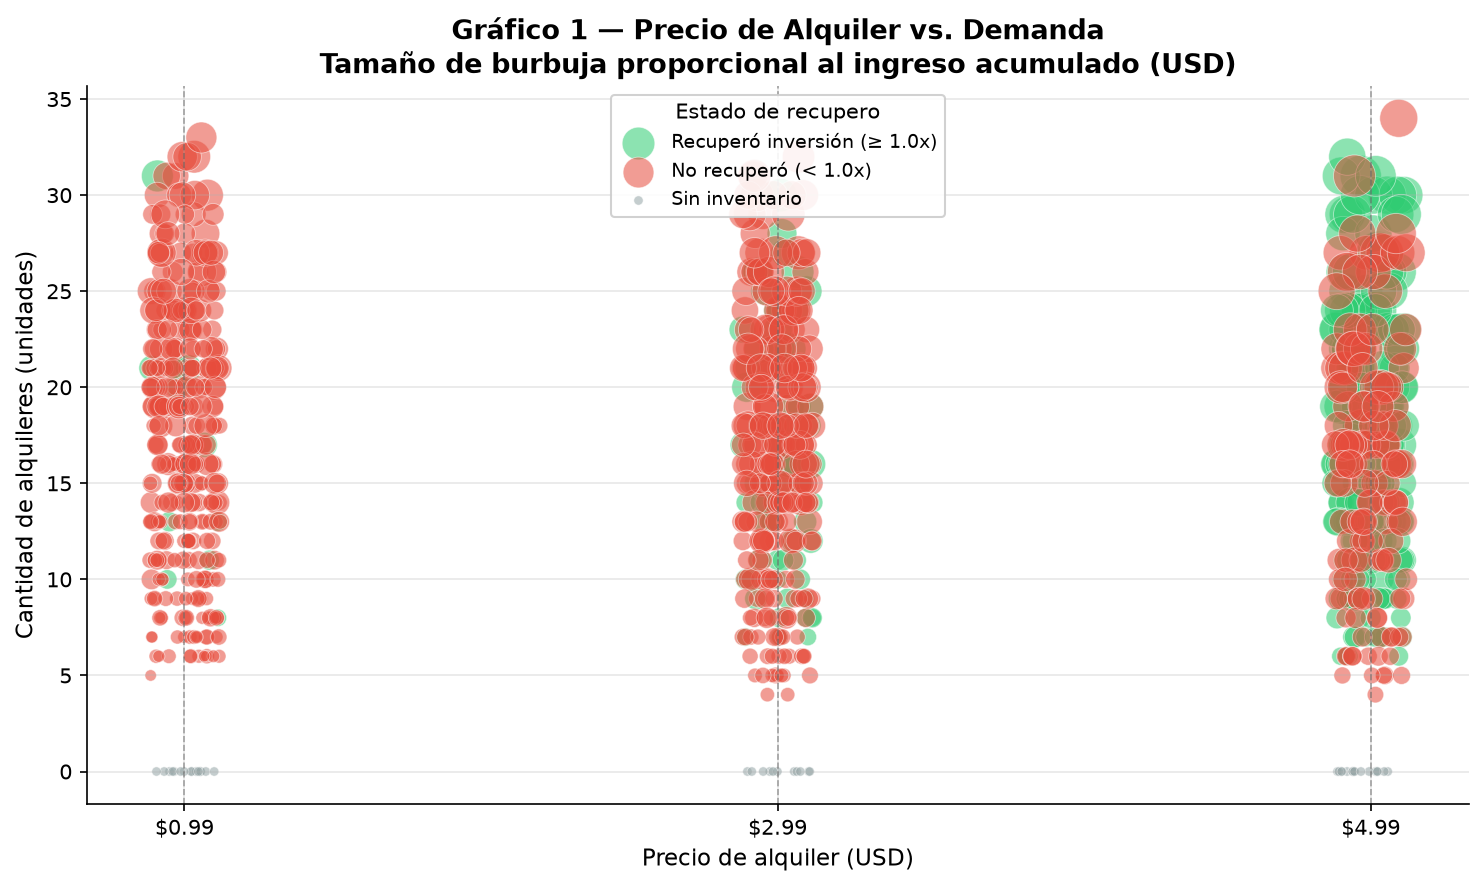

Guardado: ../graficos/g1_precio_vs_demanda_burbuja.png


In [21]:
# ─── Gráfico 1: Scatter Burbuja con Jitter ──────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

paleta = {
    'Recuperó inversión (≥ 1.0x)': '#2ecc71',
    'No recuperó (< 1.0x)':        '#e74c3c',
    'Sin inventario':              '#95a5a6',
}

np.random.seed(42)
max_revenue = df_trabajo['total_revenue'].max()

for estado, color in paleta.items():
    mask = df_trabajo['estado_recupero'] == estado
    sub = df_trabajo[mask]
    if len(sub) == 0:
        continue

    jitter = np.random.uniform(-0.12, 0.12, size=len(sub))
    x = sub['rental_rate'] + jitter

    # Escalar tamaño usando el máximo global; fallback a tamaño fijo si todo es cero
    if max_revenue > 0:
        sizes = sub['total_revenue'] / max_revenue * 400 + 20
    else:
        sizes = 30

    ax.scatter(
        x, sub['rental_count'],
        s=sizes, c=color, alpha=0.55,
        edgecolors='white', linewidths=0.4,
        label=estado
    )

for precio in [0.99, 2.99, 4.99]:
    ax.axvline(precio, color='#555', linestyle='--', linewidth=0.8, alpha=0.5)

ax.set_xlabel('Precio de alquiler (USD)', fontsize=11)
ax.set_ylabel('Cantidad de alquileres (unidades)', fontsize=11)
ax.set_title(
    'Gráfico 1 — Precio de Alquiler vs. Demanda\n'
    'Tamaño de burbuja proporcional al ingreso acumulado (USD)',
    fontsize=13, fontweight='bold'
)
ax.set_xticks([0.99, 2.99, 4.99])
ax.set_xticklabels(['$0.99', '$2.99', '$4.99'])
ax.legend(title='Estado de recupero', framealpha=0.9, fontsize=9)

plt.tight_layout()
ruta_g1 = '../graficos/g1_precio_vs_demanda_burbuja.png'
plt.savefig(ruta_g1, dpi=150, bbox_inches='tight')
plt.close()
display(IPImage(ruta_g1))
print(f'Guardado: {ruta_g1}')


### 3.3 Gráfico 2 (Adicional): Distribución del Ratio de Recupero por Precio — Boxplot

Muestra la dispersión del ratio de recupero dentro de cada estrato de precio, marcando
la línea de break-even (`ratio_recupero = 1.0`).


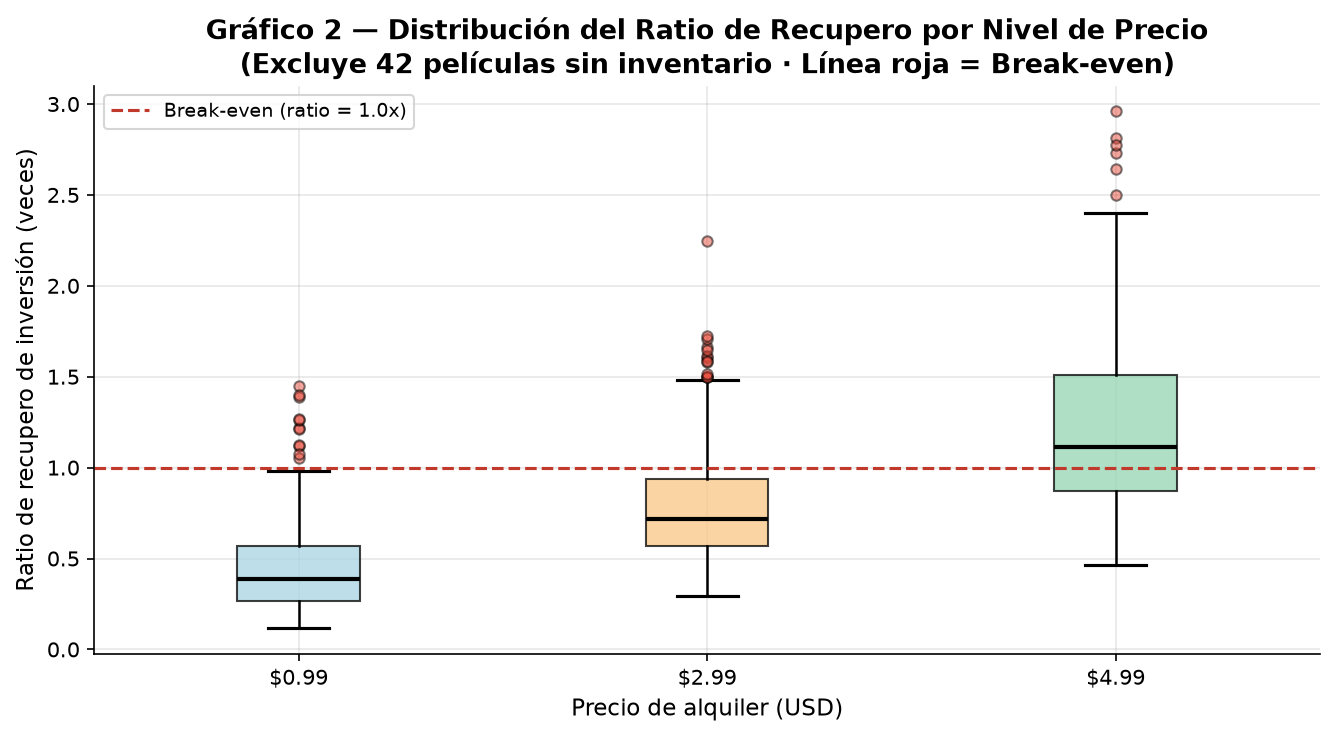

Guardado: ../graficos/g2_boxplot_ratio_recupero.png


In [22]:
# ─── Gráfico 2: Boxplot Ratio de Recupero por Nivel de Precio ───────────────
fig, ax = plt.subplots(figsize=(9, 5))

df_con_stock = df_trabajo[df_trabajo['inventory_count'] > 0].copy()
grupos = [df_con_stock[df_con_stock['rental_rate'] == p]['ratio_recupero'].values
          for p in [0.99, 2.99, 4.99]]

bp = ax.boxplot(
    grupos,
    tick_labels=['$0.99', '$2.99', '$4.99'],
    patch_artist=True,
    medianprops={'color': 'black', 'linewidth': 2},
    flierprops={'marker': 'o', 'markerfacecolor': '#e74c3c', 'markersize': 5, 'alpha': 0.5},
    whiskerprops={'linewidth': 1.2},
    capprops={'linewidth': 1.5},
)

colores_box = ['#a8d5e2', '#f9c784', '#95d5b2']
for patch, color in zip(bp['boxes'], colores_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.axhline(1.0, color='#c0392b', linestyle='--', linewidth=1.5,
           label='Break-even (ratio = 1.0x)')

ax.set_xlabel('Precio de alquiler (USD)', fontsize=11)
ax.set_ylabel('Ratio de recupero de inversión (veces)', fontsize=11)
ax.set_title(
    'Gráfico 2 — Distribución del Ratio de Recupero por Nivel de Precio\n'
    '(Excluye 42 películas sin inventario · Línea roja = Break-even)',
    fontsize=13, fontweight='bold'
)
ax.legend(fontsize=9)

plt.tight_layout()
ruta_g2 = '../graficos/g2_boxplot_ratio_recupero.png'
plt.savefig(ruta_g2, dpi=150, bbox_inches='tight')
plt.close()
display(IPImage(ruta_g2))
print(f'Guardado: {ruta_g2}')


### 3.4 Gráfico 3 (Adicional): Tasa de Éxito Comercial por Nivel de Precio — Barras Apiladas

Muestra qué porcentaje de los títulos de cada nivel de precio logró recuperar, no recuperó
o carece de stock. La lectura directa responde visualmente la pregunta de negocio de la Variante 6.


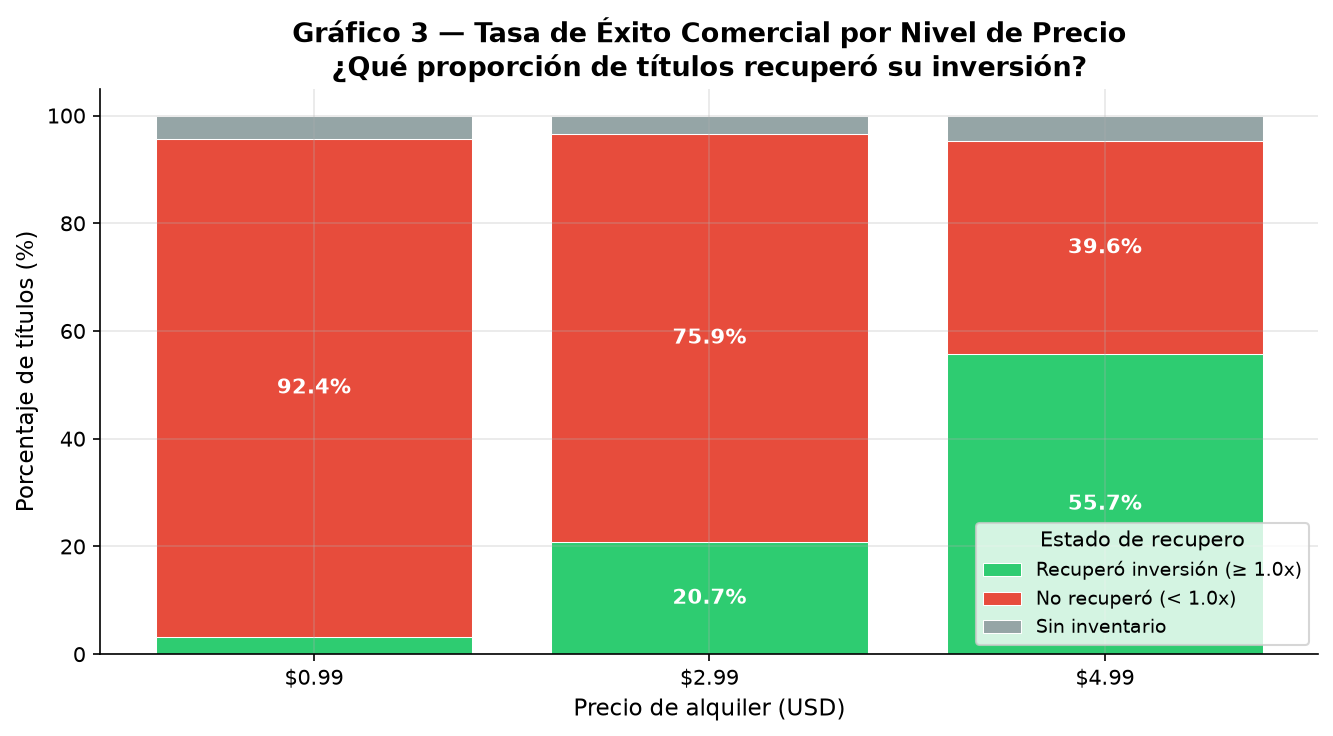

Guardado: ../graficos/g3_tasa_exito_por_precio.png


In [23]:
# ─── Gráfico 3: Barras apiladas — Tasa de Éxito por Nivel de Precio ─────────
precios = [0.99, 2.99, 4.99]
etiquetas_precio = ['$0.99', '$2.99', '$4.99']

estados_orden = ['Recuperó inversión (≥ 1.0x)', 'No recuperó (< 1.0x)', 'Sin inventario']
colores_barras = ['#2ecc71', '#e74c3c', '#95a5a6']

tabla = {}
for precio in precios:
    sub = df_trabajo[df_trabajo['rental_rate'] == precio]
    total = len(sub)
    tabla[precio] = {e: (sub['estado_recupero'] == e).sum() / total * 100
                     for e in estados_orden}

fig, ax = plt.subplots(figsize=(9, 5))
bottom = np.zeros(len(precios))

for estado, color in zip(estados_orden, colores_barras):
    vals = np.array([tabla[p][estado] for p in precios])
    bars = ax.bar(etiquetas_precio, vals, bottom=bottom,
                  color=color, label=estado, edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, vals):
        if val > 5:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + bar.get_height() / 2,
                f'{val:.1f}%',
                ha='center', va='center',
                fontsize=10, color='white', fontweight='bold'
            )
    bottom += vals

ax.set_ylim(0, 105)
ax.set_xlabel('Precio de alquiler (USD)', fontsize=11)
ax.set_ylabel('Porcentaje de títulos (%)', fontsize=11)
ax.set_title(
    'Gráfico 3 — Tasa de Éxito Comercial por Nivel de Precio\n'
    '¿Qué proporción de títulos recuperó su inversión?',
    fontsize=13, fontweight='bold'
)
ax.legend(title='Estado de recupero', loc='lower right', fontsize=9)

plt.tight_layout()
ruta_g3 = '../graficos/g3_tasa_exito_por_precio.png'
plt.savefig(ruta_g3, dpi=150, bbox_inches='tight')
plt.close()
display(IPImage(ruta_g3))
print(f'Guardado: {ruta_g3}')


### 3.5 Hallazgos Narrativos y Respuesta a la Pregunta de Negocio

---

#### Hallazgo 1 — La demanda es inelástica respecto al precio

Los tres niveles de precio presentan distribuciones de `rental_count` prácticamente idénticas.
Multiplicar el precio de alquiler por 5 (de $0.99 a $4.99) no reduce significativamente la demanda.
**La demanda está determinada por el atractivo del contenido, no por el precio unitario.**
Esto valida la estrategia de segmentación en tres tramos: los grupos son cualitativamente distintos
en rentabilidad pero no en volumen de demanda.

#### Hallazgo 2 — El precio define la velocidad de recupero, no la demanda

A $4.99, el break-even promedio es de ~4 alquileres por copia y la gran mayoría de los títulos
supera ampliamente el umbral de recupero. A $0.99, se requieren entre 11 y 30 alquileres por copia,
lo que expone a esos títulos a mayor riesgo de no amortizar el costo de reposición.
**El precio no mueve la demanda, pero sí determina la eficiencia económica del catálogo.**

#### Hallazgo 3 — El 4.2% del catálogo es costo de oportunidad no explotado

Las 42 películas sin inventario están en el catálogo pero nunca generaron ingreso ($0.00 en `total_revenue`).
Dado que la demanda demostrada es independiente del precio, incorporar copias físicas de esos títulos
tendría alta probabilidad de rentabilizarlos. **La barrera es el stock, no la demanda.**


In [24]:
# ── Verificación final de archivos generados ────────────────────────────────
import glob
pngs = sorted(glob.glob('../graficos/*.png'))
print(f'=== Gráficos exportados ({len(pngs)} archivos) ===')
for p in pngs:
    size_kb = os.path.getsize(p) / 1024
    print(f'  {os.path.basename(p)}: {size_kb:.1f} KB')


=== Gráficos exportados (3 archivos) ===
  g1_precio_vs_demanda_burbuja.png: 311.2 KB
  g2_boxplot_ratio_recupero.png: 66.1 KB
  g3_tasa_exito_por_precio.png: 72.0 KB
